In [1]:
import os, subprocess

REPO_URL = "https://github.com/tongyuguo/HelpHerInvest.git"
REPO_DIR = "HelpHerInvest"
data_dir = os.path.join(REPO_DIR, "Data")

def clone_or_pull():
    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        subprocess.run(["git", "-C", REPO_DIR, "pull"])
    else:
        subprocess.run(["git", "clone", REPO_URL])

clone_or_pull()

error: Pulling is not possible because you have unmerged files.
hint: Fix them up in the work tree, and then use 'git add/rm <file>'
hint: as appropriate to mark resolution and make a commit.
fatal: Exiting because of an unresolved conflict.


NLP model 

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
#%pip install sentence-transformers
from sentence_transformers import SentenceTransformer
import zipfile

STOCKS_CSV = "HelpHerInvest/Data/nlp_clean_stock_symbols.csv"

def load_stocks(path=STOCKS_CSV):
    df = pd.read_csv(path)

    # Choose a text field for retrieval
    df["kw_text"] = df["document_clean_tfidf"].fillna(df["document_raw"]).fillna("")
    df["sem_text"] = df["document_raw"].fillna(df["document_clean_tfidf"]).fillna("")

    # Keep only usable rows
    df = df[(df["kw_text"].str.len() > 0) & (df["sem_text"].str.len() > 0)].reset_index(drop=True)
    return df

def build_hybrid_index(df,
                       sbert_model="sentence-transformers/all-MiniLM-L6-v2",
                       tfidf_min_df=2,
                       tfidf_ngram_range=(1,2)):
    # TF-IDF for keyword similarity
    vectorizer = TfidfVectorizer(min_df=tfidf_min_df, max_df=0.95, ngram_range=tfidf_ngram_range)
    X_tfidf = vectorizer.fit_transform(df["kw_text"].astype(str))

    # SBERT embeddings for semantic similarity 
    model = SentenceTransformer(sbert_model)
    X_emb = model.encode(
        df["sem_text"].astype(str).tolist(),
        batch_size=128,
        show_progress_bar=True,
        normalize_embeddings=True
    ).astype(np.float32)

    return vectorizer, X_tfidf, model, X_emb

df_stocks = load_stocks(STOCKS_CSV)
vectorizer, X_tfidf, sbert, X_emb = build_hybrid_index(df_stocks)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

In [3]:
import numpy as np

def _minmax(x):
    x = np.asarray(x, dtype=np.float32)
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-9)

def build_query_from_df_text_inputs_row(row):
    # Use text_input if present; otherwise combine topics
    t = str(row.get("text_input", "")).strip()
    if t:
        return t
    p = str(row.get("primary_topic", "")).strip()
    s = str(row.get("secondary_topic", "")).strip()
    return (p + " " + s).strip()

def hybrid_retrieve(query, df_stocks, vectorizer, X_tfidf, sbert, X_emb,
                    top_k=50,
                    w_sem=0.65, w_kw=0.35,
                    mmr_lambda=0.80,
                    candidate_pool=500,
                    sector_cap=10):
    """
    w_sem/w_kw: weight semantic vs keyword similarity
    mmr_lambda: higher => more relevance, lower => more diversity
    candidate_pool: retrieve this many by relevance before diversifying to top_k
    sector_cap: max results per sector (set None to disable)
    """

    # keyword similarity (TF-IDF cosine for L2-normalized TF-IDF is dot product)
    q_tfidf = vectorizer.transform([query])
    kw_scores = (X_tfidf @ q_tfidf.T).toarray().ravel()

    # semantic similarity (cosine via normalized vectors)
    q_emb = sbert.encode([query], normalize_embeddings=True).astype(np.float32)  # (1, d)
    sem_scores = (X_emb @ q_emb.T).ravel()

    # combine (normalize each so neither dominates)
    kw_n = _minmax(kw_scores)
    sem_n = _minmax(sem_scores)
    scores = w_sem * sem_n + w_kw * kw_n

    # candidate set
    pool = min(candidate_pool, len(df_stocks))
    cand_idx = np.argpartition(-scores, pool-1)[:pool]
    cand_idx = cand_idx[np.argsort(-scores[cand_idx])]

    # MMR diversification using embedding similarity to reduce redundancy
    selected = []
    selected_set = set()

    # Precompute candidate embeddings
    cand_emb = X_emb[cand_idx]

    # Sector tracking
    sector_counts = {}
    def sector_ok(i):
        if sector_cap is None:
            return True
        sec = df_stocks.loc[i, "sector"]
        sec = sec if isinstance(sec, str) and sec else "Unknown"
        return sector_counts.get(sec, 0) < sector_cap

    for _ in range(min(top_k, len(cand_idx))):
        best_i = None
        best_mmr = -1e9

        for pos, i in enumerate(cand_idx):
            if i in selected_set:
                continue
            if not sector_ok(i):
                continue

            rel = scores[i]

            if not selected:
                mmr = rel
            else:
                # max similarity to already selected (redundancy)
                sim_to_selected = np.max(X_emb[i] @ X_emb[selected].T)
                mmr = mmr_lambda * rel - (1 - mmr_lambda) * sim_to_selected

            if mmr > best_mmr:
                best_mmr = mmr
                best_i = i

        if best_i is None:
            break

        selected.append(best_i)
        selected_set.add(best_i)
        sec = df_stocks.loc[best_i, "sector"]
        sec = sec if isinstance(sec, str) and sec else "Unknown"
        sector_counts[sec] = sector_counts.get(sec, 0) + 1

    out = df_stocks.loc[selected, ["symbol","company_name","sector","industry"]].copy()
    out["hybrid_score"] = scores[selected]
    out = out.sort_values("hybrid_score", ascending=False).reset_index(drop=True)
    return out

classfication model

In [4]:
import pandas as pd
#%pip install yfinance
#import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import zipfile
import requests
warnings.filterwarnings("ignore")

In [5]:
import os
print(os.getcwd())
print(os.path.exists("HelpHerInvest/Data/final_dataset_20260224v2.csv.zip"))
print(os.path.exists("Data/final_dataset_20260224v2.csv.zip"))

/home/jupyter-guotq
True
False


In [6]:
# Load the data from the zip file

## PATH NEEDS TO BE UPDATED TO GITHUB DATA PATH
zip_path2 = "HelpHerInvest/Data/final_dataset_20260224v2.csv.zip"
with zipfile.ZipFile(zip_path2) as z:
    df = pd.read_csv(z.open("final_dataset_20260224v2.csv"))

## ## ## ## 

tickers = df["Ticker"].unique()
print(f"Unique tickers in final dataset: {len(tickers)}")
print("Size of dataset:",
"Rows:",df.shape[0],
"Columns:",df.shape[1])

Unique tickers in final dataset: 1993
Size of dataset: Rows: 302024 Columns: 18


In [7]:
# count number of positive fwd_excess_return
print("Number of positive fwd_excess_return:", (df["fwd_excess"] > 0).sum())
print("Number of negative fwd_excess_return:", (df["fwd_excess"] < 0).sum())
print("Number of zero fwd_excess_return:", (df["fwd_excess"] == 0).sum())

df = df.copy()

df['y'] = (df['fwd_excess'] > 0).astype(int)

Number of positive fwd_excess_return: 143948
Number of negative fwd_excess_return: 151730
Number of zero fwd_excess_return: 287


In [8]:
# Ensure datetime
df['Date'] = pd.to_datetime(df['Date'])

# Find latest month in dataset
max_date = df['Date'].max()

# Compute cutoff
cutoff_date = max_date - pd.DateOffset(months=2)

# Subset
df_last3 = df[df['Date'] > cutoff_date].copy()
df_last3.head()

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y
296052,2025-12-31,NVDA,0.4632,-0.1615,-0.0187,-0.0007,-0.0109,-0.1615,-0.0187,-0.0007,-0.0587,-0.1146,0.0987,0.3188,0.2869,186.5000,NaN,NaN,0
296053,2025-12-31,GOOGL,-0.2588,0.9727,0.2777,0.0626,0.1162,0.9727,0.2777,0.0626,-0.2683,-0.1787,0.6149,0.7311,1.4220,313.0000,NaN,NaN,0
296054,2025-12-31,AAPL,-0.2902,0.1099,0.0543,-0.0705,-0.0779,0.1099,0.0543,-0.0705,-0.6517,-0.2838,0.5852,0.7074,0.3279,271.6058,NaN,NaN,0
296055,2025-12-31,MSFT,-0.2136,-0.4135,-0.1202,-0.0553,-0.0587,-0.4135,-0.1202,-0.0553,-0.6087,-0.3388,-0.0043,0.2366,-0.3248,482.5187,NaN,NaN,0
296056,2025-12-31,AMZN,-0.1489,0.0413,-0.0823,-0.0795,-0.0966,0.0413,-0.0823,-0.0795,-0.1768,-0.1408,0.3160,0.4923,-0.1244,230.8200,NaN,NaN,0


In [9]:
def time_split(df, date_col='Date', train_frac=0.7, val_frac=0.15):
    df = df.sort_values(date_col).copy()
    unique_dates = df[date_col].drop_duplicates().sort_values().to_numpy()

    # retreive the num of rows to create train/val/test split
    n = len(unique_dates)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train_dates = unique_dates[:train_end]
    val_dates   = unique_dates[train_end:val_end]
    test_dates  = unique_dates[val_end:]

    train = df[df[date_col].isin(train_dates)]
    val   = df[df[date_col].isin(val_dates)]
    test  = df[df[date_col].isin(test_dates)]

    return train, val, test

training_data, validation_data, testing_data = time_split(df)
print("Train size:", training_data.shape)
print("Val size:", validation_data.shape)
print("Test size:", testing_data.shape)
training_data.tail()

Train size: (193638, 19)
Val size: (52704, 19)
Test size: (55682, 19)


,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y
192479,2021-04-30,SSNC,0.2723,0.1806,-0.0387,-0.1580,-0.1615,0.1806,-0.0387,-0.1580,-0.5679,-0.0456,0.5045,0.5021,-0.3760,69.7704,0.0042,0.0585,1
192485,2021-04-30,LH,0.0402,0.0731,-0.0345,-0.0866,-0.0872,0.0731,-0.0345,-0.0866,-0.5906,-0.0432,0.5045,0.5021,0.2354,218.1971,0.0596,0.1139,1
192486,2021-04-30,IHG,-0.0824,0.0408,-0.0311,-0.1020,-0.0977,0.0408,-0.0311,-0.1020,-0.3594,-0.0339,0.5045,0.5021,-0.2273,65.4198,-0.1253,-0.0710,0
192487,2021-04-30,CHD,-0.6758,-0.6346,-0.0551,-0.1904,-0.1656,-0.6346,-0.0551,-0.1904,-0.7487,-0.0506,0.2809,-0.5392,-1.1342,80.8025,-0.0415,0.0127,0
192484,2021-04-30,NVR,0.3069,-0.0899,-0.0381,-0.0860,-0.0957,-0.0899,-0.0381,-0.0860,-0.4088,-0.0409,0.5045,0.5021,-0.1548,5018.1001,-0.0135,0.0408,0


In [10]:
def preprocess_data(df):

    # preprocess the data by dropping rows with missing values
    print("Missing fwd_excess values:")

    df_dropped = df.dropna()
    print("---  ---  ---")
    print("Length of original:",len(df.index))
    print("Length of dropped:",len(df_dropped.index))
    print("Sanity check - missing fwd_excess values after dropping:")
    print(df_dropped[["Date","Ticker","fwd_excess"]].tail(5)) 

   
    
    # Create log_adj_close column
    df_dropped["log_adj_close"] = np.log(df_dropped["adj_close"])
    df_dropped[["adj_close","log_adj_close"]].hist(figsize=(14, 10), bins=50)
    plt.tight_layout()
    plt.show()
    
    return df_dropped

Missing fwd_excess values:
---  ---  ---
Length of original: 193638
Length of dropped: 175057
Sanity check - missing fwd_excess values after dropping:
             Date Ticker  fwd_excess
192479 2021-04-30   SSNC      0.0042
192485 2021-04-30     LH      0.0596
192486 2021-04-30    IHG     -0.1253
192487 2021-04-30    CHD     -0.0415
192484 2021-04-30    NVR     -0.0135


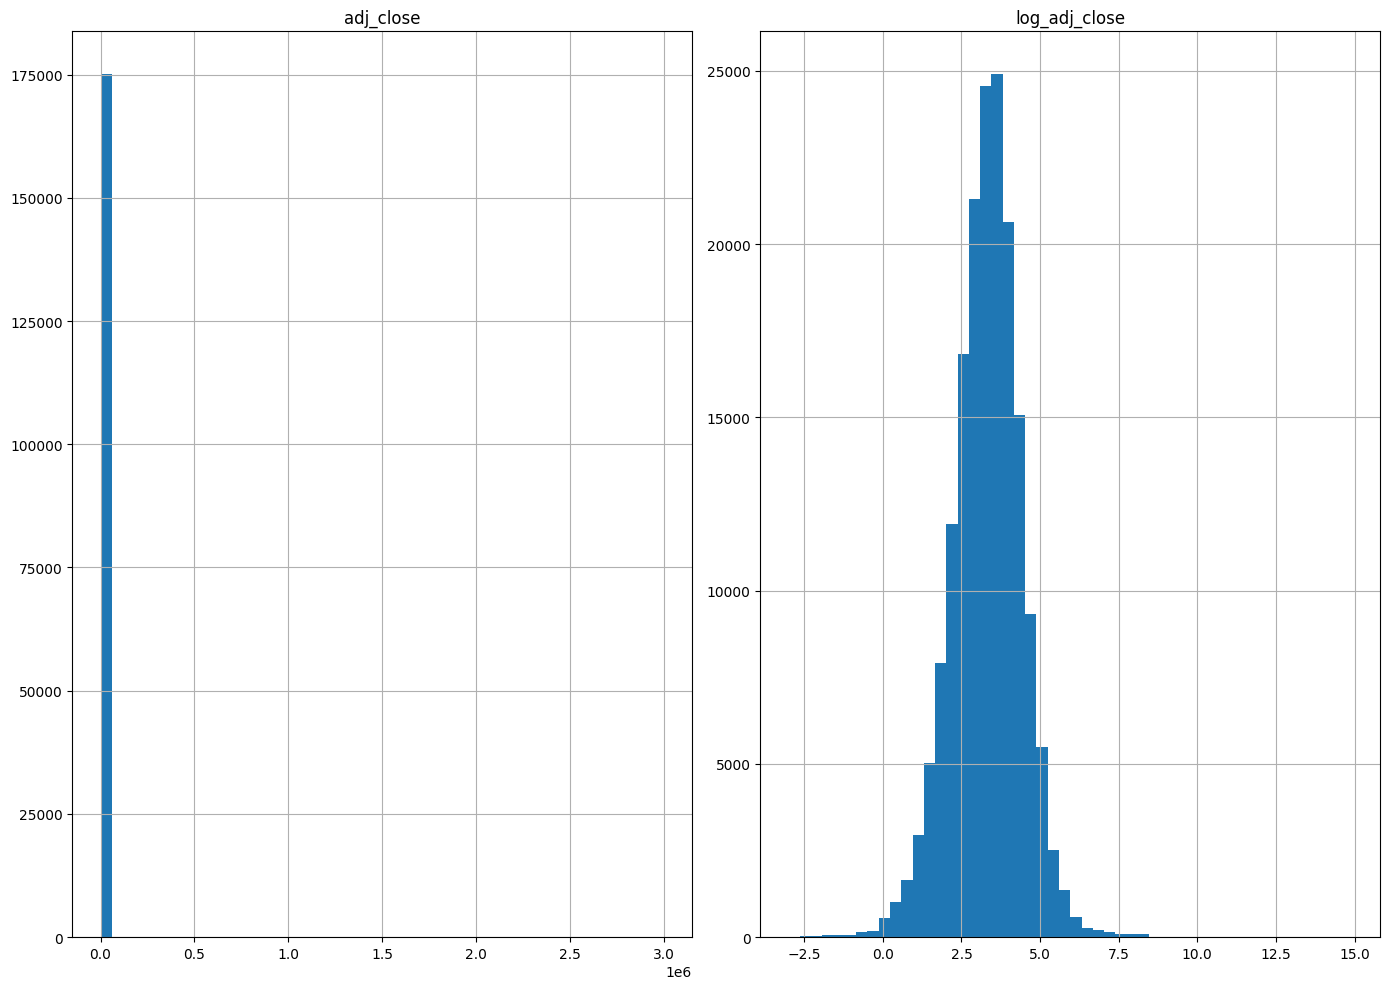

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y,log_adj_close
14213,2011-01-31,TTMI,0.4972,2.4448,1.1222,0.4989,0.3268,2.4448,1.1222,0.4989,1.9380,1.5628,0.5788,0.5941,1.7258,15.9000,0.1377,0.2025,1,2.766319
14216,2011-01-31,DSGX,-0.2733,-0.0527,-0.1622,-0.4035,-0.3472,-0.0527,-0.1622,-0.4035,-0.1112,-0.1488,0.4071,0.4935,-0.0843,6.9700,-0.1136,-0.0488,0,1.941615
14215,2011-01-31,CHDN,-0.6391,0.2684,-0.2432,-0.4573,-0.2885,0.2684,-0.2432,-0.4573,-0.2997,-0.2583,-0.2127,0.1302,-0.0399,6.2609,-0.0576,0.0072,0,1.834324
14214,2011-01-31,GSAT,-0.9448,-1.6521,-1.5770,0.1845,0.5515,-1.6521,-1.5770,0.1845,0.8672,1.1957,-3.3892,-2.4986,-1.9339,20.1000,-0.1021,-0.0373,0,3.000720
14218,2011-01-31,MASI,0.1469,-0.5690,0.3651,-0.3740,-0.4427,-0.5690,0.3651,-0.3740,0.1033,-0.0491,0.4829,0.5379,0.1353,28.5698,0.0956,0.1604,1,3.352350


In [11]:
train_df = preprocess_data(training_data)
train_df.head(5)

Missing fwd_excess values:
---  ---  ---
Length of original: 55682
Length of dropped: 48493
Sanity check - missing fwd_excess values after dropping:
             Date Ticker  fwd_excess
294730 2025-11-30    GPN      0.0285
294731 2025-11-30   BURL      0.2126
294732 2025-11-30   KTOS      0.1828
294733 2025-11-30   TRMB     -0.1891
294728 2025-11-30   SBAC      0.0290


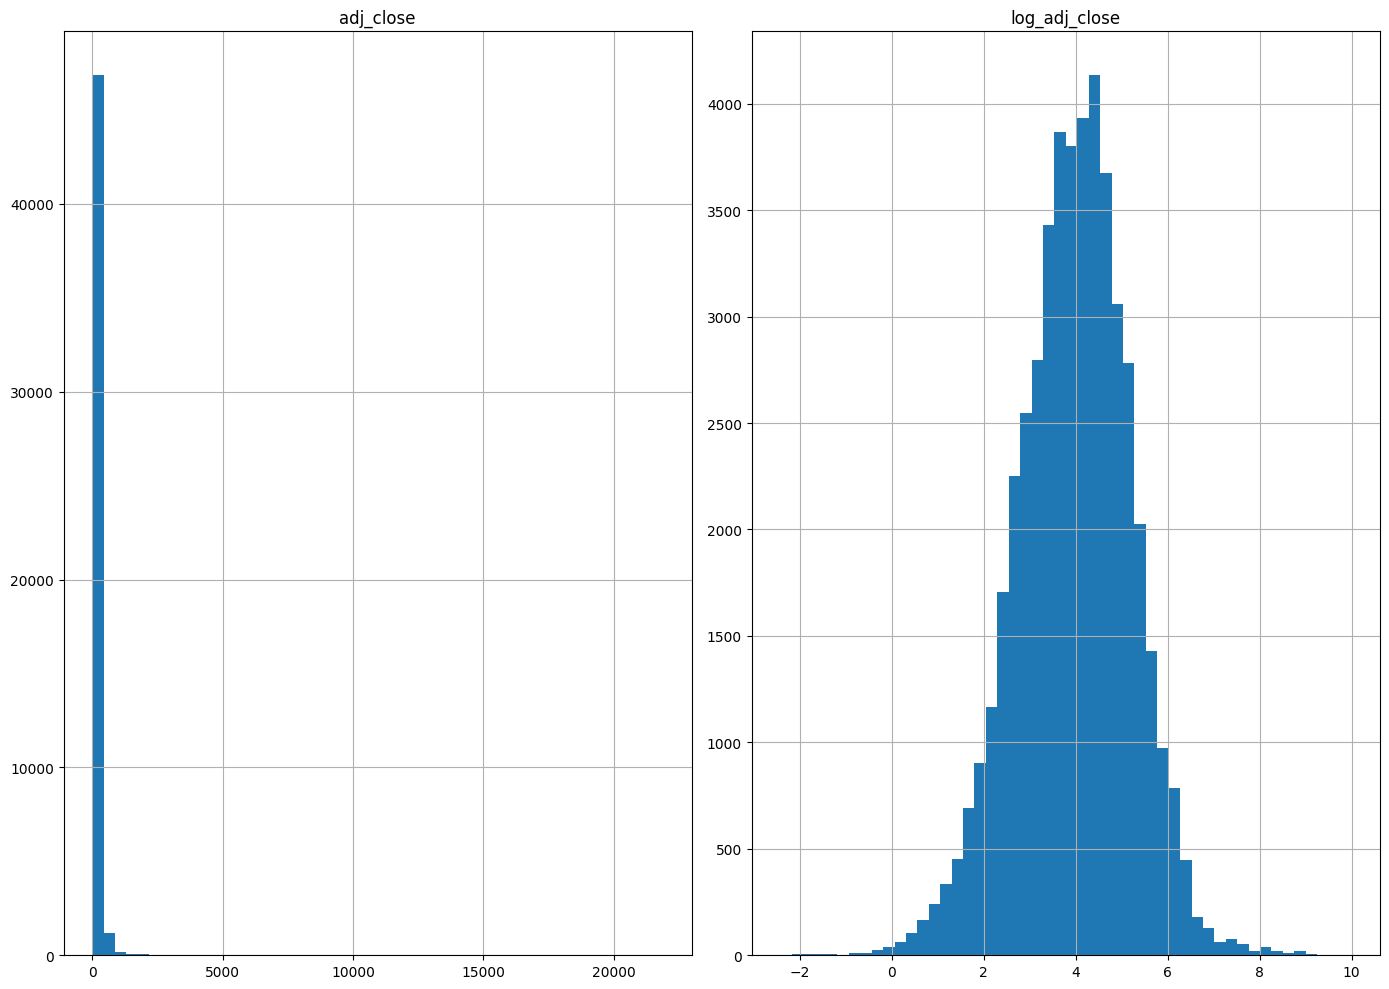

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y,log_adj_close
247583,2023-10-31,MNSO,0.2820,1.8365,1.5085,10.5307,10.4558,1.8365,1.5085,10.5307,0.8386,0.7170,1.0479,1.1475,2.2729,24.0159,-0.4893,-0.3299,0,3.178716
247584,2023-10-31,ACT,0.6388,0.7340,0.6076,0.1936,0.0074,0.7340,0.6076,0.1936,-0.5861,-0.4127,0.9323,1.0483,0.8457,25.5351,-0.0930,0.0664,0,3.240054
247585,2023-10-31,ZETA,-0.1585,-0.1970,-0.7219,-0.3790,-0.3453,-0.1970,-0.7219,-0.3790,0.8372,0.4462,0.0756,-0.4865,-0.4454,7.8000,0.0817,0.2410,1,2.054124
247586,2023-10-31,RHP,0.7997,0.1445,-0.0652,-0.2143,-0.4258,0.1445,-0.0652,-0.2143,-0.3047,-0.3832,0.5455,0.7163,0.1875,77.3804,0.1373,0.2966,1,4.348734
247592,2023-10-31,ARW,-0.4508,-0.4682,-0.0130,0.1119,0.2669,-0.4682,-0.0130,0.1119,-0.2618,-0.3952,-0.3258,-0.0314,-0.2352,113.4100,-0.1793,-0.0199,0,4.731010


In [12]:
test_df = preprocess_data(testing_data)
test_df.head(5)

Missing fwd_excess values:
---  ---  ---
Length of original: 52704
Length of dropped: 50961
Sanity check - missing fwd_excess values after dropping:
             Date Ticker  fwd_excess
245100 2023-09-30    HPQ      0.0652
245099 2023-09-30    PFG     -0.0149
245098 2023-09-30   TWLO      0.1799
245097 2023-09-30   CHRW     -0.1058
245108 2023-09-30    RCI      0.1129


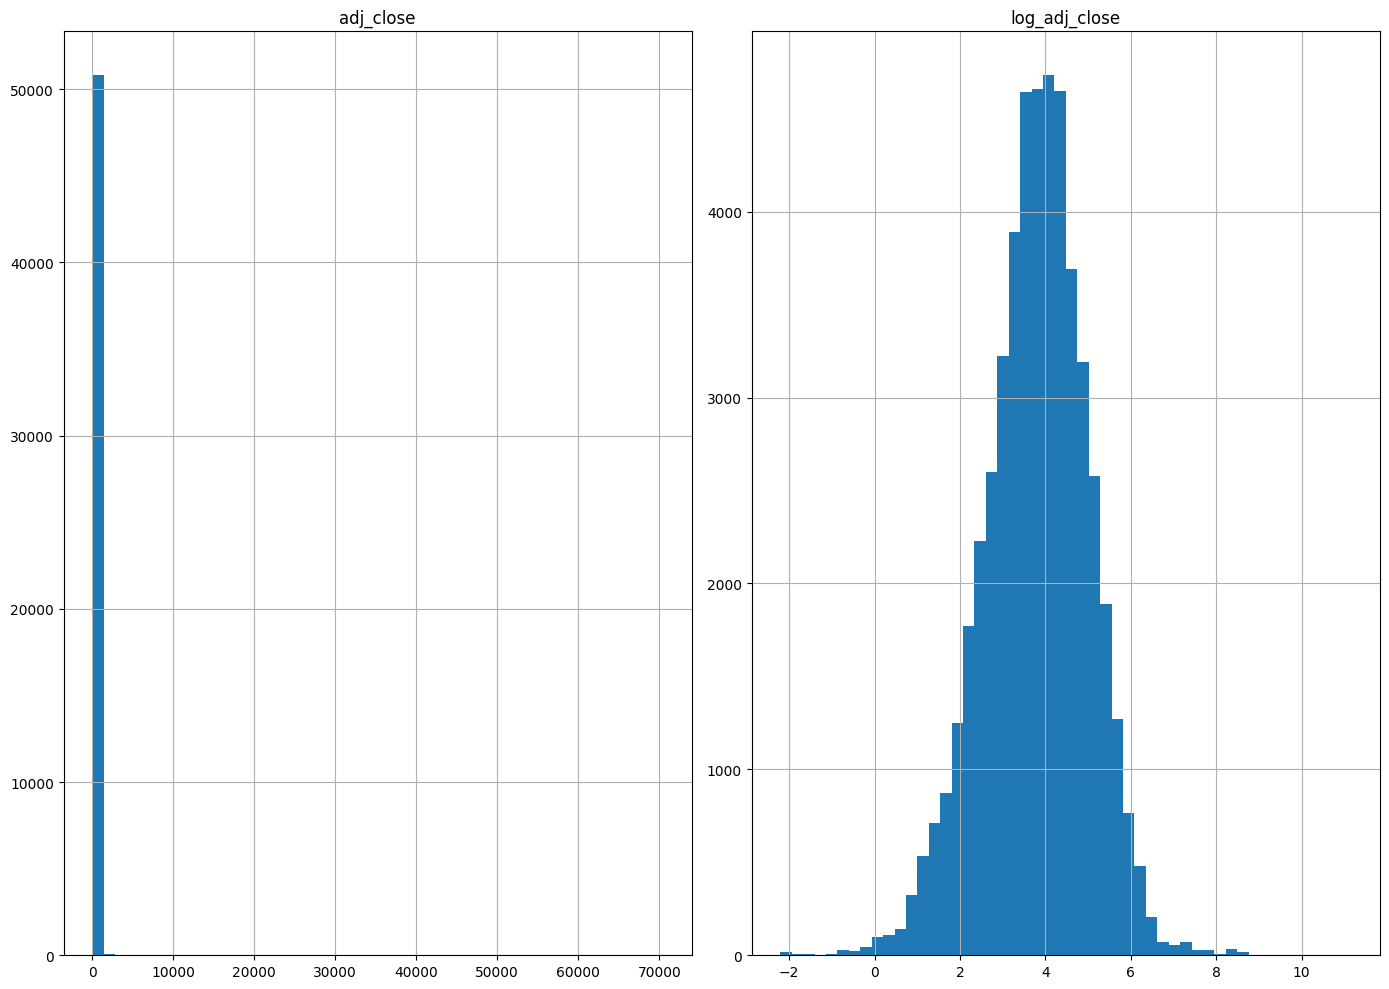

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y,log_adj_close
194796,2021-05-31,SITE,-0.6464,-0.0770,-0.0860,-0.0469,-0.0277,-0.0770,-0.0860,-0.0469,0.2931,0.1085,0.1177,0.1482,-0.2446,172.0400,0.0845,0.1631,1,5.147727
194804,2021-05-31,DLB,-0.6009,-0.5411,-0.3627,-0.0460,-0.0284,-0.5411,-0.3627,-0.0460,-0.5613,-0.5965,0.1629,0.1910,-0.3061,90.8153,-0.0602,0.0184,0,4.508828
194803,2021-05-31,M,0.8177,0.5672,1.0082,0.2009,0.1754,0.5672,1.0082,0.2009,1.2113,1.2406,0.5328,0.5413,1.7165,15.3682,0.1463,0.2248,1,2.732300
194805,2021-05-31,TRNO,-0.3711,0.2303,-0.3603,-0.1159,-0.1162,0.2303,-0.3603,-0.1159,-0.6730,-0.6928,0.3913,0.4073,-0.4687,55.7725,-0.0238,0.0548,0,4.021281
194802,2021-05-31,DAR,-0.3743,-0.0735,0.2600,0.2133,0.2577,-0.0735,0.2600,0.2133,0.4512,0.3094,-0.1731,-0.1272,0.1532,68.4600,0.0097,0.0882,1,4.226250


In [13]:
val_df = preprocess_data(validation_data)
val_df.head(5)

In [14]:
feature_cols = [col for col in train_df.columns if col not in ["Date", "Ticker", "fwd_excess", "fwd_return", "y"]]

X_train, y_train = train_df[feature_cols], train_df['y']
X_val, y_val     = val_df[feature_cols],   val_df['y']
X_test, y_test   = test_df[feature_cols],  test_df['y']

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
import numpy as np

# L1 (Lasso) Logistic Regression

model_l1 = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        penalty='l1',
        solver='saga',
        max_iter=1000
    ))
])

model_l1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logit', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with 

In [16]:
# Elastic Net Logistic Regression 

model_en = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,   # 50% L1 / 50% L2
        max_iter=1000
    ))
])

model_en.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logit', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [17]:
# Weighted Logistic Regression

model_weighted = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        class_weight='balanced',
        max_iter=500
    ))
])

model_weighted.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logit', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [18]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    print("Classification Report:\n")
    print(classification_report(y_test, y_pred))
    print("F1:", round(f1_score(y_test, y_pred, average='macro'), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, probs, average='macro'), 4))

print("L1 Logistic Regression Performance:")
evaluate(model_l1, X_val, y_val)
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("Elastic Net Logistic Regression Performance:")
evaluate(model_en, X_val, y_val)
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("Weighted Logistic Regression Performance:")
evaluate(model_weighted, X_val, y_val)

L1 Logistic Regression Performance:
Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.85      0.66     26843
           1       0.50      0.16      0.24     24118

    accuracy                           0.53     50961
   macro avg       0.52      0.51      0.45     50961
weighted avg       0.52      0.53      0.46     50961

F1: 0.45
ROC-AUC: 0.5143

-----  -----  -----  -----  -----  -----  -----  -----  -----  -----
Elastic Net Logistic Regression Performance:
Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.85      0.66     26843
           1       0.50      0.16      0.24     24118

    accuracy                           0.53     50961
   macro avg       0.52      0.51      0.45     50961
weighted avg       0.52      0.53      0.46     50961

F1: 0.4501
ROC-AUC: 0.5143

-----  -----  -----  -----  -----  -----  -----  -----  -----  -----
Weighted Logistic Regress

In [19]:
def evaluate_to_df(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    # Classification report as table
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report_dict).T

    # Add summary metrics
    report_df.loc["overall", "f1_marco"] = f1_score(y_test, y_pred, average='macro')
    report_df.loc["overall", "roc_auc"] = roc_auc_score(y_test, probs, average='macro')
    report_df["model"] = model_name

    return report_df

results = {
    "L1_LogReg": evaluate_to_df(model_l1, X_val, y_val, "L1 Logistic Regression"),
    "ElasticNet_LogReg": evaluate_to_df(model_en, X_val, y_val, "Elastic Net Logistic Regression"),
    "Weighted_LogReg": evaluate_to_df(model_weighted, X_val, y_val, "Weighted Logistic Regression"),
}

'''
# Export: one sheet per model
with pd.ExcelWriter("/Users/christoomey/Desktop/Courses/ADAN8888_Applied_Analytics_Project/Output/classification_reports.xlsx", engine="openpyxl") as writer:
    for sheet_name, df in results.items():
        df.to_excel(writer, sheet_name=sheet_name)

print("Saved to classification_reports.xlsx")
'''

'\n# Export: one sheet per model\nwith pd.ExcelWriter("/Users/christoomey/Desktop/Courses/ADAN8888_Applied_Analytics_Project/Output/classification_reports.xlsx", engine="openpyxl") as writer:\n    for sheet_name, df in results.items():\n        df.to_excel(writer, sheet_name=sheet_name)\n\nprint("Saved to classification_reports.xlsx")\n'


L1 Logistic Regression
          Pred 0  Pred 1
Actual 0   22947    3896
Actual 1   20216    3902

Elastic Net Logistic Regression
          Pred 0  Pred 1
Actual 0   22949    3894
Actual 1   20216    3902

Weighted Logistic Regression
          Pred 0  Pred 1
Actual 0   17813    9030
Actual 1   15571    8547


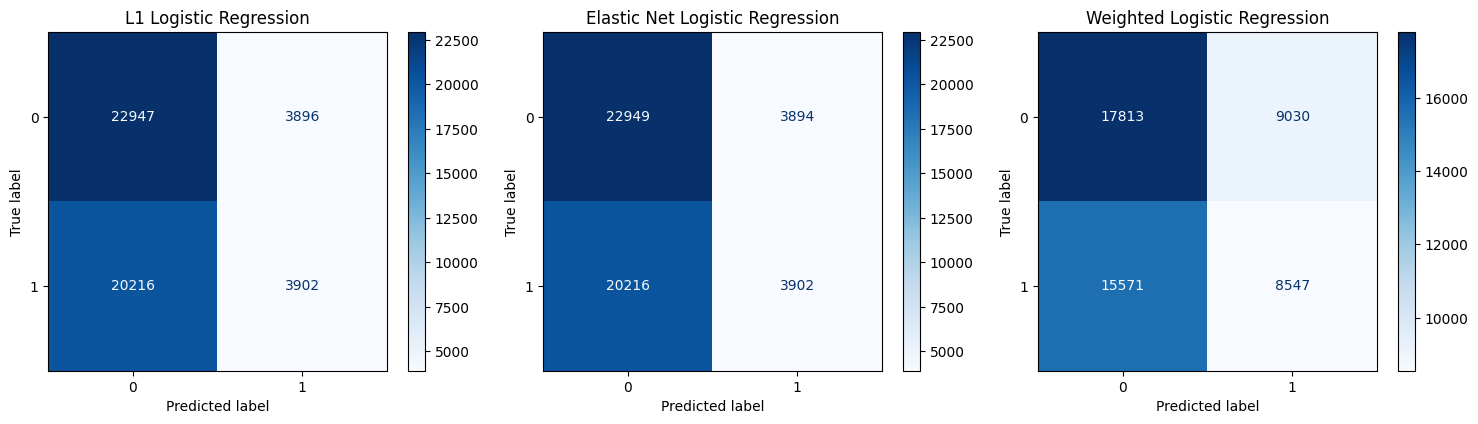

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "L1 Logistic Regression": model_l1,
    "Elastic Net Logistic Regression": model_en,
    "Weighted Logistic Regression": model_weighted
}

# 1) Print/save confusion matrix tables
cm_tables = {}
for name, model in models.items():
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)  # [[TN, FP], [FN, TP]]
    cm_df = pd.DataFrame(cm,
                         index=["Actual 0", "Actual 1"],
                         columns=["Pred 0", "Pred 1"])
    cm_tables[name] = cm_df
    print(f"\n{name}\n{cm_df}")
    
# 2) Plot confusion matrix for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_val)
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred, ax=ax, cmap="Blues", values_format="d"
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [21]:
def coef_summary(pipe, feature_cols):
    coefs = pipe.named_steps['logit'].coef_.ravel()
    return pd.Series(coefs, index=feature_cols).sort_values()

l1_coefs = coef_summary(model_l1, feature_cols)
en_coefs = coef_summary(model_en, feature_cols)
wght_coefs = coef_summary(model_weighted, feature_cols)

print("L1 coefficients:\n", l1_coefs)
print("\nElastic Net coefficients:\n", en_coefs)
print("\nWeighted Logistic Regression coefficients:\n", wght_coefs)

L1 coefficients:
 adj_close          -0.048033
log_adj_close      -0.036325
mom_1m             -0.026003
vol_3m             -0.010035
mom_12m_ex_1m      -0.008641
rel_6m_spy         -0.007025
mom_6m             -0.007025
rel_3m_spy         -0.006202
mom_3m             -0.006202
pct_above_200dma    0.011461
drawdown_6m         0.014015
mom_12m             0.014449
rel_12m_spy         0.014449
drawdown_12m        0.022568
vol_6m              0.031406
dtype: float64

Elastic Net coefficients:
 adj_close          -0.048298
log_adj_close      -0.036335
mom_1m             -0.026140
vol_3m             -0.010112
mom_12m_ex_1m      -0.009088
rel_6m_spy         -0.007086
mom_6m             -0.007086
rel_3m_spy         -0.006224
mom_3m             -0.006224
pct_above_200dma    0.011603
drawdown_6m         0.014044
mom_12m             0.014683
rel_12m_spy         0.014683
drawdown_12m        0.022563
vol_6m              0.031518
dtype: float64

Weighted Logistic Regression coefficients:
 adj_close

In [22]:
# Selected the best model from validation performance and evaluate on test set
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("Weighted Logistic Regression Performance - Test Set:")
evaluate(model_weighted, X_test, y_test)


-----  -----  -----  -----  -----  -----  -----  -----  -----  -----
Weighted Logistic Regression Performance - Test Set:
Classification Report:

              precision    recall  f1-score   support

           0       0.55      0.71      0.62     25892
           1       0.50      0.34      0.40     22601

    accuracy                           0.54     48493
   macro avg       0.53      0.52      0.51     48493
weighted avg       0.53      0.54      0.52     48493

F1: 0.512
ROC-AUC: 0.5351


In [23]:
# This is making predictions on the test set and adding the probabilities and predictions back to the testing_df for analysis
# These rows were removed from the test set due to missing values in the features, so we need to align the testing_df with the X_test_temp after dropping those rows
# i.e. it contains data with no fwd_excess and is the months 12/2025 - 2/2026

testing_df = testing_data.copy()
print(testing_df.tail(10))
testing_df["log_adj_close"] = np.log(testing_df["adj_close"])
X_test_temp = testing_df[feature_cols]
X_test_temp = X_test_temp.dropna()  # Drop rows with missing values in the features
probs = model_weighted.predict_proba(X_test_temp)[:, 1]
preds = model_weighted.predict(X_test_temp)
testing_df = testing_df.loc[X_test_temp.index]  # Align testing_df with X_test_temp after dropping rows
testing_df['prob_outperform'] = probs
testing_df['prediction'] = preds
print(testing_df[["Date", "Ticker", "fwd_excess", "prob_outperform", "prediction"]].tail(10))

             Date Ticker  mom_1m  mom_3m  mom_6m  mom_12m  mom_12m_ex_1m  \
300693 2026-02-28   KTOS -1.0123  0.5308  0.3065   0.3314         0.4328   
300692 2026-02-28   BURL  0.1883  0.6551 -0.1412  -0.0520        -0.0540   
300691 2026-02-28    GPN  0.5666 -0.1131 -0.3846  -0.1360        -0.1431   
300690 2026-02-28   APTV  0.0715 -0.2608 -0.2582  -0.0594        -0.0582   
300689 2026-02-28   SBAC  0.5890 -0.1109 -0.2403  -0.1027        -0.1121   
300688 2026-02-28  CKHGF -0.1196 -0.2683  0.0373   0.0141         0.0227   
300687 2026-02-28    WWD  1.6931  1.0531  0.6240   0.0982         0.0358   
300686 2026-02-28     BG  0.4918  0.9101  0.4426   0.0293         0.0153   
300699 2026-02-28      Q  1.4788  1.5679     NaN      NaN            NaN   
302023 2026-02-28   RXRX -1.2944 -1.2592 -0.5767  -0.1853        -0.1667   

        rel_3m_spy  rel_6m_spy  rel_12m_spy  vol_3m  vol_6m  drawdown_6m  \
300693      0.5308      0.3065       0.3314  1.4101  0.5086      -0.1534   
300692     